In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# For a simple ML pipeline
from mlresearch.datasets import ContinuousCategoricalDatasets
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

# Explainability using SHAP
import shap

# For the TabPFN
from tabpfn import TabPFNRegressor

# Set up classification problem

In [2]:
# Load data
datasets = ContinuousCategoricalDatasets(names=["GERMAN CREDIT"]).download()
df = datasets[0][-1]
continuous_columns = df.columns.drop("target").str.startswith("cat_")
X, y = df.drop(columns=["target"]), df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
datasets.summarize_datasets()

,Features,Metric,Non-Metric,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,,,
GERMAN CREDIT,20,7,13,1000,300,700,2.33,2


In [4]:
clf = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(), continuous_columns),
            ("num", "passthrough", ~continuous_columns),
        ]
    ),
    RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1),
)

clf.fit(X_train, y_train)

# Predict probabilities
prediction_probabilities = clf.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

# Predict labels
predictions = clf.predict(X_test)
print("F-Score", f1_score(y_test, predictions))

ROC AUC: 0.768167890385616
F-Score 0.8361290322580646


## SHAP

In [5]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def preprocess_data(X):
    """Preprocess the data using the fitted ColumnTransformer."""
    return clf.named_steps["columntransformer"].transform(X).astype(float)


def shap_explanations(X):
    """Compute SHAP explanations for the given data."""
    shap_explainer = shap.Explainer(
        model=clf.named_steps["randomforestclassifier"], masker=X
    )

    explanation = shap_explainer(X)
    # shap_exp = explanation.values[:, :, -1]
    return explanation


def postprocess_explanations(explanations, original_columns):
    """Postprocess SHAP explanations to match original feature names."""

    # Group one-hot encoded categorical feature
    def _fetch_original_feature_name(feature_name):
        name_list = feature_name.split("__")
        return (
            "_".join(name_list[-1].split("_")[:-1])
            if name_list[0] == "cat"
            else name_list[-1]
        )

    feature_names_out = clf.named_steps["columntransformer"].get_feature_names_out()

    df_shap = pd.DataFrame(explanations, columns=feature_names_out)
    df_shap = (
        df_shap.T.groupby(
            [_fetch_original_feature_name(col) for col in feature_names_out]
        )
        .sum()
        .T[original_columns]
    )
    return df_shap

In [6]:
# Compute SHAP explanations for the train set
X_train_preprocessed = preprocess_data(X_train)
shap_explanations_train = shap_explanations(X_train_preprocessed)
df_shap_train = postprocess_explanations(
    shap_explanations_train.values[:, :, -1], X_train.columns
)

100%|===================| 995/1000 [01:18<00:00]        

In [7]:
# Compute SHAP explanations for the test set
X_test_preprocessed = preprocess_data(X_test)
shap_explanations_test = shap_explanations(X_test_preprocessed)
df_shap_test = postprocess_explanations(
    shap_explanations_test.values[:, :, -1], X_test.columns
)

 99%|===================| 993/1000 [01:18<00:00]        

# Approximate SHAP and ShaRP explanations using TabPFN

In [9]:
df_pfn_cont_test = {}
for col_name in X_train.columns:
    pfn_contribution = TabPFNRegressor(n_estimators=1)
    pfn_contribution.fit(X_train, df_shap_train[col_name])
    df_pfn_cont_test[col_name] = pfn_contribution.predict(X_test)

df_pfn_cont_test = pd.DataFrame(df_pfn_cont_test)

/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Con

Text(0.5, 0, 'PFN-predicted contributions (test set)')

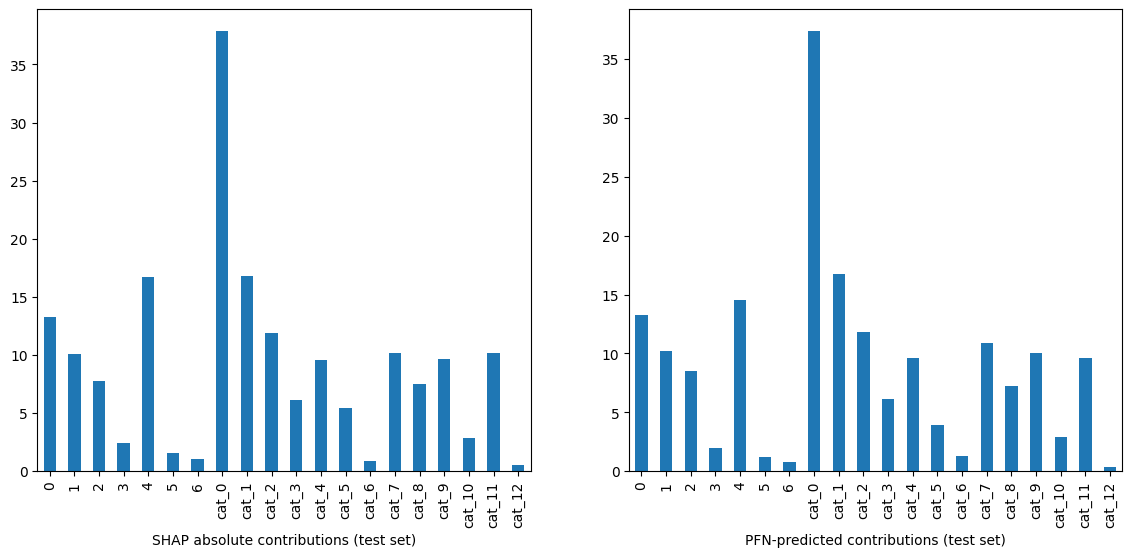

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_shap_test.abs().sum(axis=0).plot.bar(ax=axes[0])
axes[0].set_xlabel("SHAP absolute contributions (test set)")

df_pfn_cont_test.abs().sum(axis=0).plot.bar(ax=axes[1])
axes[1].set_xlabel("PFN-predicted contributions (test set)")

In [11]:
# The sum of SHAP values and base values should equal the predicted probabilities
# Here we apply a correction to the SHAP values to match the predicted probabilities
y_pred = clf.predict_proba(X_test)[:, -1]
df_pfn_cont_test  #  + (y_pred - (df_pfn_cont_test.sum(axis=1) + shap_explanations_test.base_values[:, -1]))
error = y_pred - (
    df_pfn_cont_test.sum(axis=1) + shap_explanations_test.base_values[:, -1]
)
error = (
    np.repeat(error.values.reshape(-1, 1), repeats=df_pfn_cont_test.shape[1], axis=1)
    / df_pfn_cont_test.shape[1]
)
df_pfn_cont_test_corrected = df_pfn_cont_test + error

In [12]:
# before correction
mean_squared_error(df_pfn_cont_test, df_shap_test)

np.float64(6.897502547118821e-05)

In [13]:
# after correction
mean_squared_error(df_pfn_cont_test_corrected, df_shap_test)

np.float64(6.092933791455578e-05)

# Varying background data

In [14]:
X_test.shape

(500, 20)

In [15]:
sensitivity_results = {}

for n_obs in tqdm(np.clip(2 ** (np.arange(1, 10)), 0, X_train.shape[0])):
    X_train_sample = X_train.sample(n=n_obs, random_state=42)

    # Compute SHAP explanations
    X_train_preprocessed = preprocess_data(X_train_sample)
    shap_explanations_train = shap_explanations(X_train_preprocessed)
    df_shap_train_sample = postprocess_explanations(
        shap_explanations_train.values[:, :, -1], X_train_sample.columns
    )

    start = time.time()
    df_pfn_cont_test = {}
    for col_name in X_train_sample.columns:
        pfn_contribution = TabPFNRegressor(n_estimators=1)
        pfn_contribution.fit(X_train_sample, df_shap_train_sample[col_name])
        df_pfn_cont_test[col_name] = pfn_contribution.predict(X_test)

    df_pfn_cont_test = pd.DataFrame(df_pfn_cont_test)
    end = time.time()

    # Apply the correction to the SHAP values to match the predicted probabilities
    y_pred = clf.predict_proba(X_test)[:, -1]
    error = y_pred - (
        df_pfn_cont_test.sum(axis=1) + shap_explanations_test.base_values[:, -1]
    )
    error = (
        np.repeat(
            error.values.reshape(-1, 1), repeats=df_pfn_cont_test.shape[1], axis=1
        )
        / df_pfn_cont_test.shape[1]
    )
    df_pfn_cont_test_corrected = df_pfn_cont_test + error

    sensitivity_results[n_obs] = {
        "original": df_pfn_cont_test,
        "corrected": df_pfn_cont_test_corrected,
        "time": end - start,
    }

  0%|          | 0/9 [00:00<?, ?it/s]

 99%|===================| 506/512 [00:37<00:00]        /var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/anonymoususer/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:494: UserWarning: Run

In [16]:
# Check mean errors
error = []
train_sizes = []
for n_obs, results in sensitivity_results.items():
    mean_error = mean_squared_error(results["corrected"], df_shap_test)
    error.append(mean_error)
    train_sizes.append(n_obs)
    print(
        f"MSE for {n_obs} observations: {mean_error:.4f} (time: {results['time']:.2f}s)"
    )

MSE for 2 observations: 0.0008 (time: 37.35s)
MSE for 4 observations: 0.0007 (time: 49.88s)
MSE for 8 observations: 0.0005 (time: 52.90s)
MSE for 16 observations: 0.0003 (time: 54.58s)
MSE for 32 observations: 0.0002 (time: 47.66s)
MSE for 64 observations: 0.0001 (time: 49.25s)
MSE for 128 observations: 0.0001 (time: 65.09s)
MSE for 256 observations: 0.0001 (time: 106.09s)
MSE for 500 observations: 0.0001 (time: 223.18s)


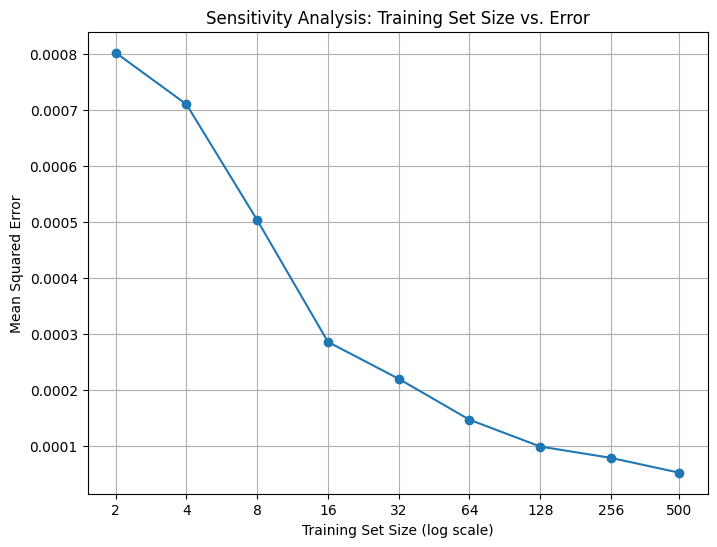

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, error, marker="o")
plt.xscale("log", base=2)
plt.xticks(train_sizes, labels=train_sizes)
plt.xlabel("Training Set Size (log scale)")
plt.ylabel("Mean Squared Error")
plt.title("Sensitivity Analysis: Training Set Size vs. Error")
plt.grid()
plt.show()